<a href="https://colab.research.google.com/github/Yesid-Valencia/Deep-Learning---Especializacion-IA/blob/main/R1-A3-S7_Red_Neuronal_Frutas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar librerias - Herramientas
Preparacion de entorno de trabajo

In [21]:
# Traemos numpy para operaciones matemáticas y arreglos
import numpy as np
# Traemos pandas para estructurar los datos en tablas
import pandas as pd
# Traemos pyplot para dibujar los gráficos
import matplotlib.pyplot as plt

# Importamos tensorflow para el motor de aprendizaje profundo
import tensorflow as tf
# Importamos keras como la interfaz amigable para armar la red
from tensorflow import keras
# Traemos las capas y los callbacks directamente para usarlos más fácil
from keras import layers, callbacks

# Traemos la función para dividir el dataset en conjuntos
from sklearn.model_selection import train_test_split
# Traemos el escalador para normalizar nuestras variables
from sklearn.preprocessing import StandardScaler
# Traemos las métricas esenciales para evaluar cómo le va al modelo
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Fijamos una semilla para que las pruebas siempre den el mismo resultado
SEED = 42
# Aplicamos la semilla a numpy
np.random.seed(SEED)
# Aplicamos la semilla a tensorflow
tf.random.set_seed(SEED)

Crear el dataset de frutas

In [27]:
from google.colab import files

files.upload()

df = pd.read_csv("dataset_frutas_redes_III.csv")

display(df.head())
print("Cantidad de frutas:", len(df))


,peso_g,tamano_cm,nivel_amarillo,clase,fruta
0,150,7.5,0.08,0,MANZANA
1,160,8.0,0.10,0,MANZANA
2,145,7.2,0.05,0,MANZANA
3,170,8.3,0.15,0,MANZANA
4,155,7.8,0.12,0,MANZANA


Cantidad de frutas: 60


Separar Train, Dev y Test

In [28]:
# Extraemos las características numéricas de las frutas
X = df[["peso_g", "tamano_cm", "nivel_amarillo"]].values
# Extraemos la etiqueta de clase que queremos predecir
y = df["clase"].values

# Dividimos los datos para quedarnos con el 60% para entrenar y el 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=SEED,
    stratify=y
)

# Del 40% temporal sacamos la mitad para validación (DEV) y la otra mitad para test final
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Mostramos el tamaño del set de entrenamiento
print("TRAIN:", X_train.shape)
# Mostramos el tamaño del set de validación o desarrollo
print("DEV:", X_dev.shape)
# Mostramos el tamaño del set de examen final
print("TEST:", X_test.shape)

TRAIN: (36, 3)
DEV: (12, 3)
TEST: (12, 3)


Escalar los datos

In [30]:
# Creamos el objeto escalador estandarizador
scaler = StandardScaler()

# Calculamos los límites y escalamos el set de entrenamiento
X_train = scaler.fit_transform(X_train)
# Escalamos el set de desarrollo con los parámetros del de entrenamiento
X_dev = scaler.transform(X_dev)
# Escalamos el set de prueba con los mismos parámetros del de entrenamiento
X_test = scaler.transform(X_test)

# Echamos un vistazo a las primeras 5 filas transformadas
print(X_train[:5])

[[ 0.98738906 -0.68546114 -0.22606732]
 [ 0.07030944 -0.76245522 -1.14348961]
 [ 0.84065632 -0.72395818 -0.31485012]
 [-0.88345337  1.73985223  1.49040019]
 [-0.92013655  1.6051126   1.46080592]]


Construir una sola red sencilla

In [31]:
# Definimos la función para fabricar el modelo con un optimizador personalizado
def crear_modelo(optimizador):
    # Definimos la arquitectura secuencial de la red
    modelo = keras.Sequential([
        # Indicamos que recibiremos 3 características de entrada
        layers.Input(shape=(3,)),
        # Añadimos una capa oculta de 8 neuronas con activación ReLU
        layers.Dense(8, activation="relu"),
        # Añadimos la capa de salida para 3 clases usando Softmax
        layers.Dense(3, activation="softmax")
    ])

    # Compilamos la red con su función de pérdida y métricas de desempeño
    modelo.compile(
        optimizer=optimizador,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    # Retornamos el modelo ya listo
    return modelo

# Creamos el modelo base usando el optimizador Adam
modelo_base = crear_modelo(
    keras.optimizers.Adam(learning_rate=0.001)
)

# Imprimimos el resumen de la estructura del modelo
modelo_base.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenar durante varias épocas

In [32]:
# Entrenamos el modelo base guardando los resultados del proceso
historial = modelo_base.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=40,
    batch_size=8,
    verbose=0
)

# Imprimimos la precisión final de entrenamiento redondeada
print("Accuracy TRAIN final:", round(historial.history["accuracy"][-1], 4))
# Imprimimos la precisión final del set de desarrollo redondeada
print("Accuracy DEV final:", round(historial.history["val_accuracy"][-1], 4))

Accuracy TRAIN final: 0.9444
Accuracy DEV final: 0.8333


Ver Train y Dev en una gráfica

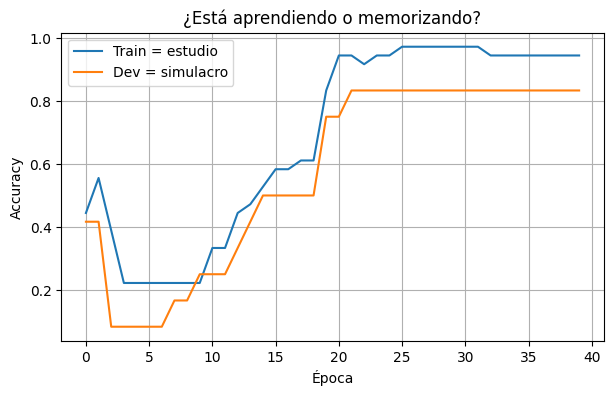

In [33]:
plt.figure(figsize=(7,4))
plt.plot(historial.history["accuracy"], label="Train = estudio")
plt.plot(historial.history["val_accuracy"], label="Dev = simulacro")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("¿Está aprendiendo o memorizando?")
plt.legend()
plt.grid(True)
plt.show()


Early Stopping: saber cuándo detenerse

In [37]:
parar = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

modelo_early = crear_modelo(
    keras.optimizers.Adam(learning_rate=0.001)
)

historial_early = modelo_early.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=100,
    batch_size=8,
    callbacks=[parar],
    verbose=0
)

print("Épocas realmente utilizadas:", len(historial_early.history["loss"]))



Épocas realmente utilizadas: 100


Comparar dos optimizadores: SGD y Adam

In [38]:
configuraciones = {
    "SGD": lambda: keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    "Adam": lambda: keras.optimizers.Adam(
        learning_rate=0.001
    )
}

resultados = []

for nombre, fabrica in configuraciones.items():
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    modelo = crear_modelo(fabrica())

    h = modelo.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=30,
        batch_size=8,
        verbose=0
    )

    resultados.append({
        "Optimizador": nombre,
        "Train Accuracy": h.history["accuracy"][-1],
        "Dev Accuracy": h.history["val_accuracy"][-1],
        "Dev Loss": h.history["val_loss"][-1]
    })

resultado_opt = pd.DataFrame(resultados)
display(resultado_opt)


,Optimizador,Train Accuracy,Dev Accuracy,Dev Loss
0,SGD,1.0,0.916667,0.194069
1,Adam,1.0,0.916667,0.745587


Agregar Dropout de forma sencilla

In [39]:
# Definimos una nueva red con regularización para evitar el sobreajuste
modelo_reg = keras.Sequential([
    # Capa de entrada que recibe las 3 variables de las frutas
    layers.Input(shape=(3,)),
    # Capa oculta con 12 neuronas y activación ReLU
    layers.Dense(12, activation="relu"),
    # Apagamos el 20% de las neuronas al azar en cada paso de entrenamiento
    layers.Dropout(0.20),
    # Capa final para determinar la probabilidad de las 3 clases
    layers.Dense(3, activation="softmax")
])

# Compilamos la red regularizada usando Adam
modelo_reg.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Creamos el callback de Early Stopping para parar si deja de mejorar
parar_reg = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Entrenamos la red con dropout y early stopping
historial_reg = modelo_reg.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=100,
    batch_size=8,
    callbacks=[parar_reg],
    verbose=0
)

Presentar el examen final: Test

In [40]:
probabilidades = modelo_reg.predict(X_test, verbose=0)
y_pred = np.argmax(probabilidades, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


Matriz de confusión 3 × 3

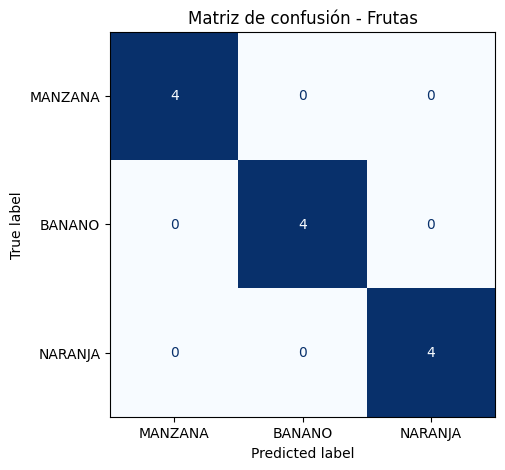

In [41]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["MANZANA", "BANANO", "NARANJA"]
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de confusión - Frutas")
plt.show()


Ver el reporte completo por fruta

In [42]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["MANZANA", "BANANO", "NARANJA"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

     MANZANA       1.00      1.00      1.00         4
      BANANO       1.00      1.00      1.00         4
     NARANJA       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



#  Resumen de la Arquitectura de nuestra Red Neuronal

Para resolver este problema de clasificación de frutas (manzanas, bananos y naranjas), diseñamos una red neuronal secuencial bastante eficiente. Así es como funciona paso a paso:

1. **Capa de Entrada (Input Layer):**
   * **¿Qué hace?** Recibe las características medidas de cada fruta.
   * **Dimensión:** `3` neuronas (una para el **peso**, otra para el **tamaño** y otra para el **nivel de amarillo**).

2. **Capa Oculta (Hidden Layer):**
   * **¿Qué hace?** Combina estas características para encontrar patrones o relaciones complejas.
   * **Neuronas:** `12` neuronas que se activan mediante la función **ReLU** (que ayuda a la red a aprender relaciones no lineales).
   * **Regularización (Dropout):** Aplicamos un **Dropout del 20%** (`0.20`). Esto significa que en cada paso del entrenamiento 'apagamos' al azar 2 de cada 10 neuronas para evitar que la red memorice los datos de entrenamiento (sobreajuste o *overfitting*) y así aprenda a generalizar mejor.

3. **Capa de Salida (Output Layer):**
   * **¿Qué hace?** Nos entrega la predicción final.
   * **Neuronas:** `3` neuronas (una para cada clase de fruta: Manzana, Banano o Naranja).
   * **Activación:** Usamos la función **Softmax**, que convierte las salidas de la red en probabilidades que suman 100% (por ejemplo, nos dice que hay un 95% de probabilidad de que sea un banano).